# PokeDATA by Monte Gardiner

## Exploring different pokemon and their statistics as well as competitive usage up through generation 4 of the PokeDex.

### First let's read in the data and check out their shapes

In [21]:
import pandas as pd

poke = pd.read_csv("../data/raw/pokeapi_gen4_raw.csv")
smog = pd.read_csv("../data/raw/smogon_gen4_usage_raw.csv")
merged = pd.read_csv("../data/raw/merged_gen4_raw.csv")

print("Poke Data shape:", poke.shape)
print("Smogon Data shape:", smog.shape)
print("Complete Merged Data shape:", merged.shape)

print("\nSmogon tiers:")
print(smog["tier"].value_counts())

print("\nSmogon unique mons:", smog["name_key"].nunique())

Poke Data shape: (493, 15)
Smogon Data shape: (113, 6)
Complete Merged Data shape: (493, 19)

Smogon tiers:
tier
gen4ou    113
Name: count, dtype: int64

Smogon unique mons: 113


### Unveiling the Base Stats
Now that our data is merged and cleaned, let's take a peek under the hood. We're going to focus primarily on **Base Stat Total (BST)**. Think of BST as a Pokémon's overall power level, it's the sum of its Health, Attack, Defense, Special Attack, Special Defense, and Speed. By looking at the summary statistics, we can get a baseline idea of how strong the average Generation 4 Pokémon actually is.

In [22]:
df = pd.read_csv("../data/cleaned/pokemon_gen4_competitive.csv")

print(df.shape)
df.head()
df["best_tier"].value_counts(dropna=False)
df["bst"].describe()

(493, 25)


count    493.000000
mean     414.707911
std      111.590333
min      180.000000
25%      320.000000
50%      420.000000
75%      495.000000
max      720.000000
Name: bst, dtype: float64

### Handling Single-Typed Pokémon
Not every Pokémon is blessed with two elemental types! About half the Pokémon in our dataset only have a single primary type (represented as `NaN` or missing in the `type2` column). Even though they lack a secondary typing, we absolutely need to keep them in our dataset because many single-type Pokémon are top-tier threats in competitive play.

In [23]:
df = pd.read_csv("../data/cleaned/pokemon_gen4_competitive.csv")

print("shape:", df.shape)
print("missing type2:", df["type2"].isna().mean())
print("OU-used mons:", (df["usage_ou"] > 0).sum())
print(df["best_tier"].value_counts(dropna=False))

shape: (493, 25)
missing type2: 0.5233265720081136
OU-used mons: 108
best_tier
NaN       385
gen4ou    108
Name: count, dtype: int64


### The Elite: OverUsed (OU) Tier
To figure out what makes a Pokémon competitively viable, we need to know which ones actually *are* viable. In the Smogon competitive community, the standard play tier is called **OverUsed (OU)**. If a Pokémon is used enough to be in OU, it's considered a top-tier threat. Let's see how many of our 493 Pokémon actually made the cut into this exclusive club.

In [24]:
df = pd.read_csv("../data/cleaned/pokemon_gen4_competitive.csv")
df["is_ou"].value_counts()

is_ou
0    385
1    108
Name: count, dtype: int64

### Visualizing the Overall Power Level
Let's graph the distribution of Base Stat Totals (BST) across all 493 Pokémon. Looking at this histogram, you'll notice it's not a perfectly smooth bell curve. Most fully-evolved Pokémon group up in the 400-500 range. But look at that sharp spike right at 600! That's completely intentional by the game developers, they designed specific 'pseudo-legendary' and mythical Pokémon to hit exactly 600 BST to make them feel exceptionally powerful.

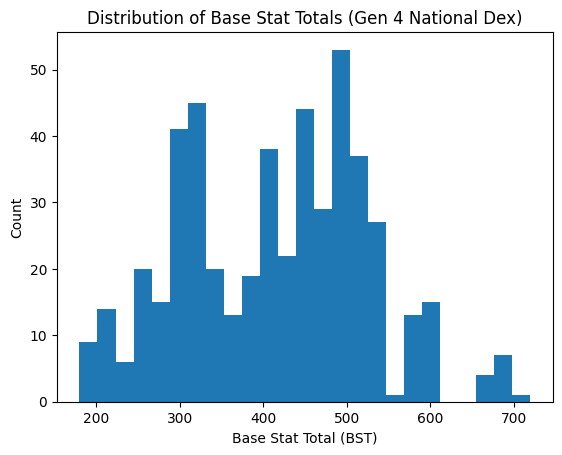

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/cleaned/pokemon_gen4_competitive.csv")

plt.figure()
plt.hist(df["bst"], bins=25)
plt.xlabel("Base Stat Total (BST)")
plt.ylabel("Count")
plt.title("Distribution of Base Stat Totals (Gen 4 National Dex)")
plt.show()

### Does Raw Power Guarantee Competitive Success?
Now for the million-dollar question: does having huge stats automatically make a Pokémon OverUsed (OU)?

To answer this, I've split the Pokémon into two groups (OU vs. Non-OU) and visualized their Base Stat Totals using a boxplot. Right away, it's clear that stats *do* matter—the median power level for OU Pokémon is visibly much higher. But, check out those dots stretching toward the bottom in the OU category! Those outliers are Pokémon with surprisingly low stats that still manage to dominate the competitive scene. This tells us that while raw power is a massive advantage, it's not the only way to win. Strategy, move sets, and elemental matchups are just as crucial.

<Figure size 640x480 with 0 Axes>

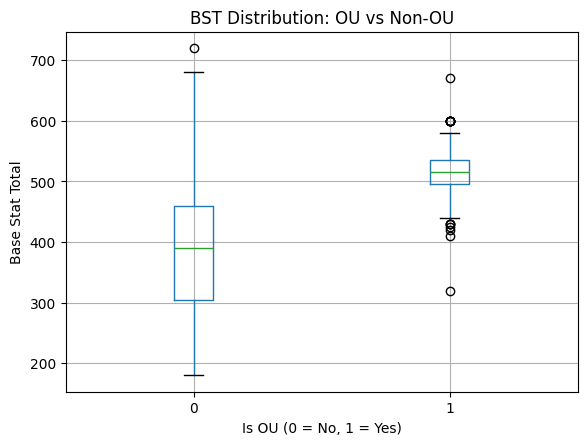

In [26]:
plt.figure()
df.boxplot(column="bst", by="is_ou")
plt.suptitle("")
plt.title("BST Distribution: OU vs Non-OU")
plt.xlabel("Is OU (0 = No, 1 = Yes)")
plt.ylabel("Base Stat Total")
plt.show()

### The Power of Elemental Typing
If raw stats aren't everything, then what else drives a Pokémon to the top? Elemental typing is a massive factor! Typing determines what attacks a Pokémon resists and what it's weak to. Let's examine the primary typings of the Pokémon that made it into the elite OU tier to see if any specific types reign supreme.

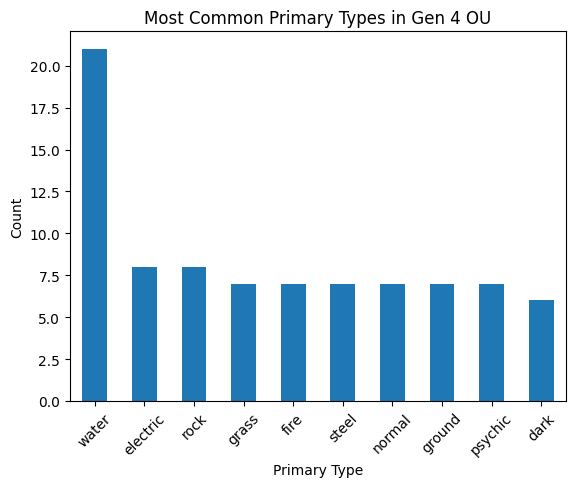

In [27]:
ou_df = df[df["is_ou"] == 1]

type_counts = ou_df["type1"].value_counts().head(10)

plt.figure()
type_counts.plot(kind="bar")
plt.title("Most Common Primary Types in Gen 4 OU")
plt.xlabel("Primary Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### What Does the Typing Tell Us?
The results are incredibly revealing! Competitive players heavily favor Pokémon that are primarily Steel, Water, and Dragon types. Why? Well these are just conjectures but, Steel is notoriously the best defensive type in the game, resisting a huge number of attacks. Water is also defensively incredibly solid with only two weaknesses(also is generally faster), and Dragon types are almost universally powerhouses with incredible offensive coverage. 

Ultimately, this proves that a fantastic defensive typing can completely make up for lower overall stats, while a poor typing can hold back even the strongest Pokémon. From this data we can see that most people agree, competitive viability isn't just a basic numbers game... It's a delicate balance of statistical brute force and strategic elemental typing.